# template

## file overview

In [1]:
import os
import glob
import random
import numpy as np
import mne
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.stats import entropy

DATA_DIR = "./data/ds004148"

subjects = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*")))

rest_files = {}
task_files = {}

for subj_path in subjects:
    subj = os.path.basename(subj_path)
    eeg_path = os.path.join(subj_path, "ses-session1", "eeg")

    # Rest: eyesclosed and eyesopen
    rest_closed = glob.glob(os.path.join(eeg_path, "*task-eyesclosed*_eeg.vhdr"))
    rest_open = glob.glob(os.path.join(eeg_path, "*task-eyesopen*_eeg.vhdr"))
    rest = rest_closed + rest_open

    # Task: everything that's NOT eyesclosed or eyesopen
    all_task = glob.glob(os.path.join(eeg_path, "*task-*_eeg.vhdr"))
    task = [t for t in all_task if "task-eyesclosed" not in t and "task-eyesopen" not in t]

    if len(rest) > 0:
        rest_files[subj] = rest  # Now rest is a list of files
    if len(task) > 0:
        task_files[subj] = task  # Or decide how to handle multiple tasks

subjects = sorted(rest_files.keys())
subjects

['sub-13',
 'sub-14',
 'sub-15',
 'sub-22',
 'sub-23',
 'sub-24',
 'sub-25',
 'sub-40',
 'sub-47',
 'sub-49']

## feature functions

In [3]:
import numpy as np
from scipy.signal import welch, butter, filtfilt, hilbert
from scipy.stats import entropy
from itertools import product

# ============================================
# PARAMETERS
# ============================================
TARGET_SFREQ = 125
WINDOW_SEC = 0.25
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

CHANNEL = "Pz"

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

band_names = list(bands.keys())

CFC_PAIRS = [
    (low, high)
    for low, high in product(band_names, band_names)
    if bands[low][1] < bands[high][0]
]

# ============================================
# SIGNAL LOADING
# ============================================
def load_signal(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if CHANNEL not in raw.ch_names:
            return None

        raw.pick([CHANNEL])
        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        x = raw.get_data()[0]
        return x if np.all(np.isfinite(x)) else None

    except:
        return None

# ============================================
# FEATURES
# ============================================

def hjorth_activity(x):
    """Hjorth activity = variance of signal"""
    return np.var(x)

def hjorth_mobility(x):
    """Hjorth mobility = sqrt(var(diff(signal)) / var(signal))"""
    if len(x) < 2:
        return np.nan
    activity = np.var(x)
    if activity == 0:
        return np.nan
    diff1 = np.diff(x)
    mobility = np.sqrt(np.var(diff1) / activity)
    return mobility

def hjorth_complexity(x):
    """Hjorth complexity = mobility(diff(signal)) / mobility(signal)"""
    if len(x) < 3:
        return np.nan

    mobility_signal = hjorth_mobility(x)
    if np.isnan(mobility_signal) or mobility_signal == 0:
        return np.nan

    diff1 = np.diff(x)
    mobility_diff = hjorth_mobility(diff1)
    if np.isnan(mobility_diff):
        return np.nan

    complexity = mobility_diff / mobility_signal
    return complexity

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    return entropy(psd / total)

def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    total = np.sum(psd)
    if total == 0:
        return np.nan
    p = psd / total
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

def bandpower(psd, freqs, band):
    idx = (freqs >= band[0]) & (freqs <= band[1])
    return np.trapz(psd[idx], freqs[idx]) if np.any(idx) else 0

def band_power_features(x, fs, bands):
    """Extract band power features (normalized)"""
    # freqs, psd = welch(x, fs=fs, nperseg=min(len(x), fs*2))
    freqs, psd = welch(x, fs=TARGET_SFREQ, nperseg=len(x))
    # Calculate raw band powers
    band_powers_raw = {}
    for band_name, (low, high) in bands.items():
        mask = (freqs >= low) & (freqs < high)
        if np.any(mask):
            band_powers_raw[band_name] = np.trapz(psd[mask], freqs[mask])
        else:
            band_powers_raw[band_name] = 0

    # Normalize
    total_power = sum(band_powers_raw.values())
    if total_power > 0:
        band_powers_norm = {k: v / total_power for k, v in band_powers_raw.items()}
    else:
        band_powers_norm = {k: np.nan for k in band_powers_raw.keys()}

    return band_powers_norm#, freqs, psd

def lempel_ziv(x):
    b = (x > np.mean(x)).astype(int)
    s = ''.join(b.astype(str))

    i, k, c = 0, 1, 1
    while i + k <= len(s):
        if s[i:i+k] in s[:i+k-1]:
            k += 1
        else:
            c += 1
            i += k
            k = 1

    return c / (len(s) / np.log2(len(s) + 1))


def cfc_pair(x, fs, low, high):
    try:
        nyq = fs / 2

        b1, a1 = butter(4, [low[0]/nyq, low[1]/nyq], btype='band')
        b2, a2 = butter(4, [high[0]/nyq, high[1]/nyq], btype='band')

        phase = np.angle(hilbert(filtfilt(b1, a1, x)))
        amp = np.abs(hilbert(filtfilt(b2, a2, x)))

        bins = np.linspace(-np.pi, np.pi, 18)
        idx = np.digitize(phase, bins)

        m = np.array([
            amp[idx == i].mean() if np.any(idx == i) else 0
            for i in range(1, len(bins))
        ])

        m /= (m.sum() + 1e-12)
        return entropy(m)

    except:
        return np.nan

# ============================================
# WINDOWING
# ============================================
def window_signal(x):
    for i in range(len(x) // WINDOW_LEN):
        yield x[i*WINDOW_LEN:(i+1)*WINDOW_LEN]

## config features

In [4]:
FEATURE_SET = [
    "hjorth",
    "spectral",
    "bandpower",
    "lzc",
    "cfc",
]

In [5]:
def extract_features(x):
    feats = {}

    # ============================================
    # Hjorth features
    # ============================================
    if "hjorth" in FEATURE_SET:
        activity = hjorth_activity(x)
        mobility = hjorth_mobility(x)
        complexity = hjorth_complexity(x)

        log_activity = np.log1p(activity) if activity > 0 else np.nan
        log_mobility = np.log1p(mobility) if not np.isnan(mobility) and mobility > 0 else np.nan
        log_complexity = np.log1p(complexity) if not np.isnan(complexity) and complexity > 0 else np.nan

        feats["hjorth_activity"] = activity
        feats["hjorth_mobility"] = mobility
        feats["hjorth_complexity"] = complexity

        feats["hjorth_log_activity"] = log_activity
        feats["hjorth_log_mobility"] = log_mobility
        feats["hjorth_log_complexity"] = log_complexity

    # ============================================
    # Spectral features
    # ============================================
    if "spectral" in FEATURE_SET:
        freqs, psd = welch(x, fs=TARGET_SFREQ, nperseg=min(len(x), TARGET_SFREQ * 2))

        feats["spectral_entropy"] = spectral_entropy(psd)
        feats["spectral_complexity"] = spectral_complexity(psd)

    # ============================================
    # Bandpower (normalized)
    # ============================================
    if "bandpower" in FEATURE_SET:
        band_powers = band_power_features(x, TARGET_SFREQ, bands)

        for band in bands.keys():
            feats[f"{band}_power"] = band_powers[band]

    # ============================================
    # Lempel-Ziv
    # ============================================
    if "lzc" in FEATURE_SET:
        feats["lzc"] = lempel_ziv(x)

    # ============================================
    # CFC
    # ============================================
    if "cfc" in FEATURE_SET:
        for low, high in CFC_PAIRS:
            feats[f"cfc_{low}_{high}"] = cfc_pair(
                x, TARGET_SFREQ, bands[low], bands[high]
            )

    return feats

## build dataset

In [6]:
def build_dataset(subjects_subset, label, files_dict):
    data = []
    global feature_names

    for subj in subjects_subset:
        for f in files_dict[subj]:
            x = load_signal(f)
            if x is None:
                continue

            for w in window_signal(x):
                feats = extract_features(w)

                vals = np.array(list(feats.values()), dtype=np.float64)

                if not np.all(np.isfinite(vals)):
                    continue

                if feature_names is None:
                    feature_names = list(feats.keys())

                data.append((list(feats.values()), label, subj))

    return data


# ============================================
# SUBJECT SPLIT
# ============================================
random.seed(42)

all_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

n_train = int(0.7 * len(all_subjects))
train_subjects = random.sample(all_subjects, n_train)
test_subjects = [s for s in all_subjects if s not in train_subjects]

print("Train subjects:", len(train_subjects))
print("Test subjects:", len(test_subjects))


# ============================================
# BUILD DATA
# ============================================
feature_names = None
all_data = []

# train
all_data += build_dataset(train_subjects, 0, rest_files)
all_data += build_dataset(train_subjects, 1, task_files)

# test
all_data += build_dataset(test_subjects, 0, rest_files)
all_data += build_dataset(test_subjects, 1, task_files)

# ============================================
# STRUCTURE
# ============================================
X = np.array([d[0] for d in all_data])
y = np.array([d[1] for d in all_data])
subjects_arr = np.array([d[2] for d in all_data])

print("Total windows:", len(X))
print("Features:", len(feature_names))

# masks
train_mask = np.isin(subjects_arr, train_subjects)
test_mask = np.isin(subjects_arr, test_subjects)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

Train subjects: 7
Test subjects: 3


/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_76387/2647074728.py:117: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band_powers_raw[band_name] = np.trapz(psd[mask], freqs[mask])


Total windows: 60450
Features: 20


## model and results

In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.58      0.32      0.41      7254
           1       0.65      0.85      0.74     10881

    accuracy                           0.64     18135
   macro avg       0.62      0.58      0.58     18135
weighted avg       0.63      0.64      0.61     18135

ROC-AUC: 0.6245982270489329


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=100,
    max_depth=1,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.55      0.31      0.40      7254
           1       0.64      0.83      0.72     10881

    accuracy                           0.62     18135
   macro avg       0.59      0.57      0.56     18135
weighted avg       0.60      0.62      0.59     18135

ROC-AUC: 0.6226281019365147


## feature importances


Top features:
                  feature  importance
3     hjorth_log_activity    0.305014
10            alpha_power    0.268823
0         hjorth_activity    0.205681
11             beta_power    0.064202
2       hjorth_complexity    0.057029
5   hjorth_log_complexity    0.054435
1         hjorth_mobility    0.044817


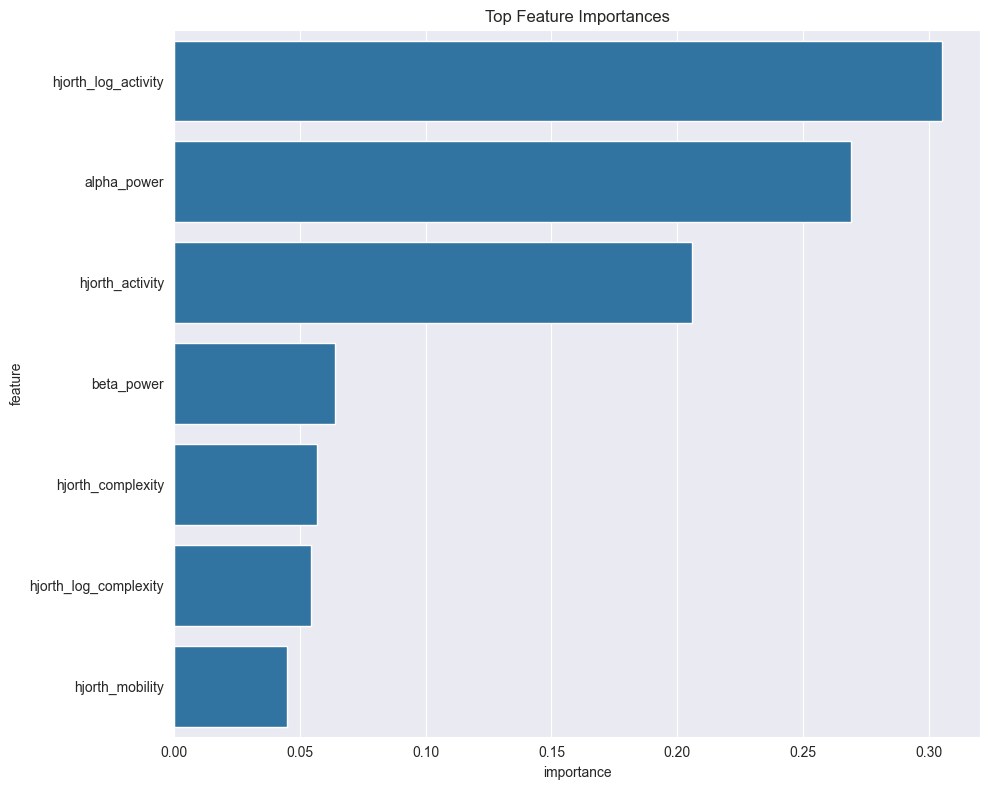


Grouped importance:
group
hjorth       0.666975
bandpower    0.333025
cfc          0.000000
lzc          0.000000
spectral     0.000000
Name: importance, dtype: float32


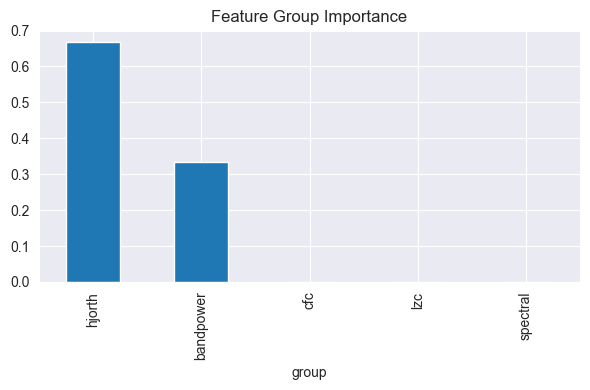

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# INDIVIDUAL FEATURE IMPORTANCE
# ============================================
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop features:")
print(importance_df.head(20)[importance_df["importance"]>0])


# Plot top features
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20)[importance_df["importance"]>0],
    x="importance",
    y="feature"
)
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()


# ============================================
# GROUPED IMPORTANCE (UPDATED)
# ============================================
def feature_group(name):
    # Hjorth (raw + log)
    if name.startswith("hjorth"):
        return "hjorth"

    # Spectral
    if name.startswith("spectral"):
        return "spectral"

    # Bandpower (normalized)
    if name.endswith("_power"):
        return "bandpower"

    # CFC
    if name.startswith("cfc"):
        return "cfc"

    # LZC
    if name == "lzc":
        return "lzc"

    return "other"


importance_df["group"] = importance_df["feature"].apply(feature_group)

grouped = (
    importance_df
    .groupby("group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\nGrouped importance:")
print(grouped)


# Plot grouped importance
plt.figure(figsize=(6, 4))
grouped.plot(kind="bar")
plt.title("Feature Group Importance")
plt.tight_layout()
plt.show()

# template multiple

In [18]:
import numpy as np

TARGET_SFREQ = 125
WINDOW_SEC = 0.25
WINDOW_LEN = int(WINDOW_SEC * TARGET_SFREQ)

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

# Toggle features here
FEATURE_SET = [
    "hjorth",
    "spectral",
    "bandpower",
    "coherence",   # connectivity
]

In [19]:
import mne

def load_signal_all_channels(file):
    try:
        raw = mne.io.read_raw_brainvision(file, preload=True, verbose=False)

        if raw.info["bads"]:
            raw.drop_channels(raw.info["bads"])

        raw.notch_filter(50, verbose=False)
        raw.filter(1, 40, verbose=False)
        raw.resample(TARGET_SFREQ)

        data = raw.get_data()  # (channels, samples)

        if not np.all(np.isfinite(data)):
            return None, None

        if np.any(np.std(data, axis=1) < 1e-10):
            return None, None

        return data, raw.ch_names

    except:
        return None, None

In [20]:
from scipy.signal import welch, coherence
from scipy.stats import entropy
from itertools import combinations

def hjorth_activity(x):
    return np.var(x)

def hjorth_mobility(x):
    if len(x) < 2:
        return np.nan
    v = np.var(x)
    if v == 0:
        return np.nan
    return np.sqrt(np.var(np.diff(x)) / v)

def hjorth_complexity(x):
    m = hjorth_mobility(x)
    if np.isnan(m) or m == 0:
        return np.nan
    return hjorth_mobility(np.diff(x)) / m

def spectral_entropy(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    return entropy(p)

def spectral_complexity(psd):
    psd = np.nan_to_num(psd)
    p = psd / (np.sum(psd) + 1e-12)
    uniform = np.ones_like(p) / len(p)
    return entropy(p, uniform)

## feature extraction

In [21]:
def extract_features_window(data, ch_names):
    feats = {}
    n_channels = len(ch_names)

    # ============================================
    # PER-CHANNEL FEATURES
    # ============================================
    for i, ch in enumerate(ch_names):
        x = data[i]

        freqs, psd = welch(x, fs=TARGET_SFREQ, nperseg=min(len(x), TARGET_SFREQ*2))

        # Hjorth
        if "hjorth" in FEATURE_SET:
            a = hjorth_activity(x)
            m = hjorth_mobility(x)
            c = hjorth_complexity(x)

            feats[f"{ch}_hjorth_activity"] = a
            feats[f"{ch}_hjorth_mobility"] = m
            feats[f"{ch}_hjorth_complexity"] = c

            feats[f"{ch}_hjorth_log_activity"] = np.log1p(a) if a > 0 else np.nan
            feats[f"{ch}_hjorth_log_mobility"] = np.log1p(m) if m > 0 else np.nan
            feats[f"{ch}_hjorth_log_complexity"] = np.log1p(c) if c > 0 else np.nan

        # Spectral
        if "spectral" in FEATURE_SET:
            feats[f"{ch}_spectral_entropy"] = spectral_entropy(psd)
            feats[f"{ch}_spectral_complexity"] = spectral_complexity(psd)

        # Bandpower
        if "bandpower" in FEATURE_SET:
            total = 0
            bp = {}

            for b, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs < high)
                val = np.trapz(psd[mask], freqs[mask]) if np.any(mask) else 0
                bp[b] = val
                total += val

            for b in bp:
                feats[f"{ch}_{b}_power"] = bp[b] / total if total > 0 else np.nan

    # ============================================
    # COHERENCE (connectivity)
    # ============================================
    if "coherence" in FEATURE_SET:
        max_ch = min(8, n_channels)  # limit explosion

        for i, j in combinations(range(max_ch), 2):
            x = data[i]
            y = data[j]

            freqs, coh = coherence(x, y, fs=TARGET_SFREQ,
                                   nperseg=min(len(x), TARGET_SFREQ*2))

            for b, (low, high) in bands.items():
                mask = (freqs >= low) & (freqs <= high)
                if np.any(mask):
                    feats[f"coh_{ch_names[i]}_{ch_names[j]}_{b}"] = np.mean(coh[mask])

    return feats

## dataset construction

In [22]:
all_data = []
feature_names = None

valid_subjects = sorted(set(rest_files.keys()) & set(task_files.keys()))

for subj in valid_subjects:

    # -------- REST --------
    for f in rest_files[subj]:
        data, ch_names = load_signal_all_channels(f)
        if data is None:
            continue

        for i in range(data.shape[1] // WINDOW_LEN):
            w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

            if np.any(np.std(w, axis=1) < 1e-10):
                continue

            feats = extract_features_window(w, ch_names)

            vals = np.array(list(feats.values()))
            if not np.all(np.isfinite(vals)):
                continue

            if feature_names is None:
                feature_names = list(feats.keys())

            all_data.append((vals, 0, subj))

    # -------- TASK --------
    for f in task_files[subj]:
        data, ch_names = load_signal_all_channels(f)
        if data is None:
            continue

        for i in range(data.shape[1] // WINDOW_LEN):
            w = data[:, i*WINDOW_LEN:(i+1)*WINDOW_LEN]

            if np.any(np.std(w, axis=1) < 1e-10):
                continue

            feats = extract_features_window(w, ch_names)

            vals = np.array(list(feats.values()))
            if not np.all(np.isfinite(vals)):
                continue

            all_data.append((vals, 1, subj))

X_all = np.array([d[0] for d in all_data])
y_all = np.array([d[1] for d in all_data])
subjects_all = np.array([d[2] for d in all_data])

print("Total windows:", len(X_all))
print("Features:", X_all.shape[1])

/var/folders/xx/gr06b4bj2cz8c5ht9dyhgzlr0000gn/T/ipykernel_76387/2427551622.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.trapz(psd[mask], freqs[mask]) if np.any(mask) else 0


Total windows: 60450
Features: 905


## split subjects

In [23]:
unique_subjects = np.unique(subjects_all)

np.random.seed(42)
train_subjects = np.random.choice(unique_subjects, int(0.7*len(unique_subjects)), replace=False)
test_subjects = np.array([s for s in unique_subjects if s not in train_subjects])

train_mask = np.isin(subjects_all, train_subjects)
test_mask = np.isin(subjects_all, test_subjects)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

## model and results

In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.75      0.25      0.37      7254
           1       0.65      0.95      0.77     10881

    accuracy                           0.67     18135
   macro avg       0.70      0.60      0.57     18135
weighted avg       0.69      0.67      0.61     18135

ROC-AUC: 0.6663621783311031


## feature importance

                      feature  importance
380    Oz_hjorth_log_activity    0.034118
604       T8_spectral_entropy    0.030888
377        Oz_hjorth_activity    0.026307
602    T8_hjorth_log_mobility    0.020872
390        O1_hjorth_activity    0.019320
393    O1_hjorth_log_activity    0.015969
599        T8_hjorth_mobility    0.014925
407   Fpz_hjorth_log_mobility    0.012119
395  O1_hjorth_log_complexity    0.011143
276   TP9_hjorth_log_activity    0.010475
394    O1_hjorth_log_mobility    0.010426
1         Fp1_hjorth_mobility    0.010075
677      TP10_hjorth_mobility    0.009829
404       Fpz_hjorth_mobility    0.009611
550   FT8_hjorth_log_mobility    0.009061
547       FT8_hjorth_mobility    0.009026
768       PO8_hjorth_mobility    0.008611
378        Oz_hjorth_mobility    0.008462
601    T8_hjorth_log_activity    0.008437
680  TP10_hjorth_log_mobility    0.008349


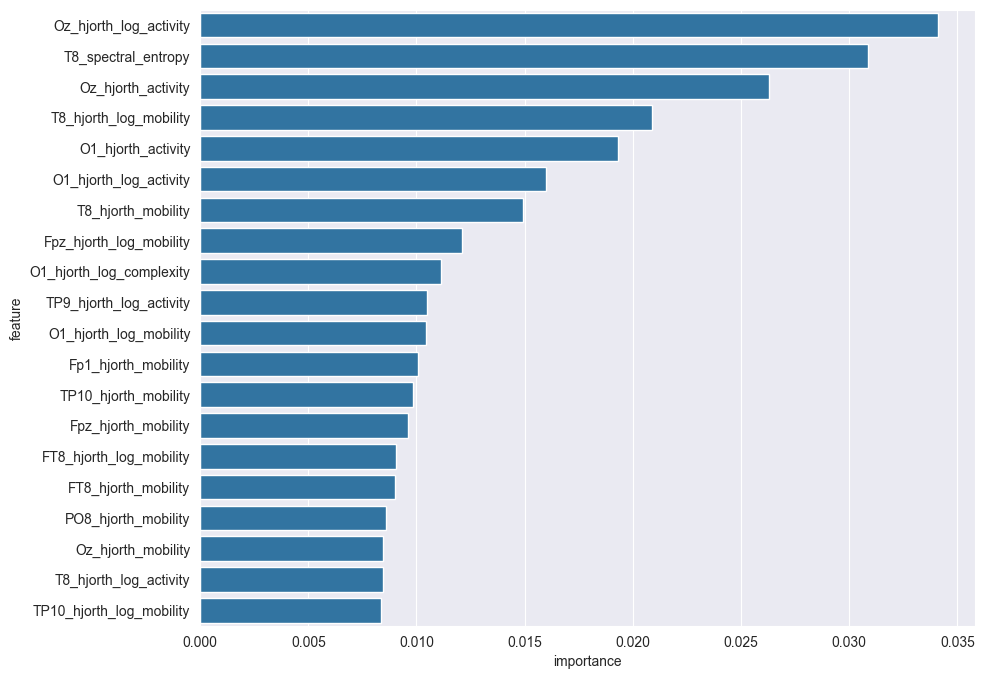

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.head(20))

plt.figure(figsize=(10,8))
sns.barplot(data=importance_df.head(20), x="importance", y="feature")
plt.show()

## try out stumps

In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = XGBClassifier(
    n_estimators=100,
    max_depth=1,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.76      0.22      0.34      7254
           1       0.65      0.95      0.77     10881

    accuracy                           0.66     18135
   macro avg       0.70      0.59      0.56     18135
weighted avg       0.69      0.66      0.60     18135

ROC-AUC: 0.6646513120471871



Grouped feature importance:
group
hjorth       0.813194
bandpower    0.127485
spectral     0.059321
coherence    0.000000
Name: importance, dtype: float32


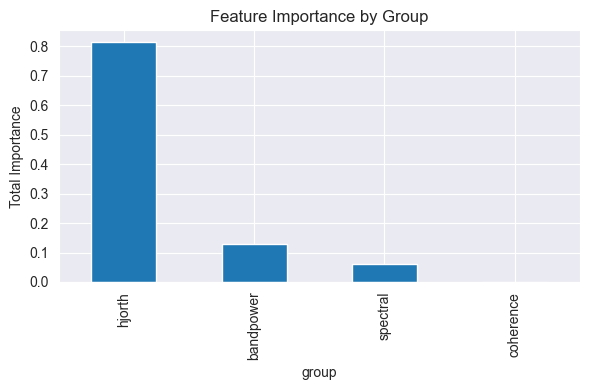

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# GROUPING FUNCTION (multi-channel aware)
# ============================================
def feature_group(name):
    # Coherence (connectivity)
    if name.startswith("coh_"):
        return "coherence"

    # Bandpower
    if name.endswith("_power"):
        return "bandpower"

    # Spectral
    if "spectral_" in name:
        return "spectral"

    # Hjorth (raw + log)
    if "hjorth" in name:
        return "hjorth"

    return "other"


# ============================================
# APPLY GROUPING
# ============================================
importance_df["group"] = importance_df["feature"].apply(feature_group)

grouped = (
    importance_df
    .groupby("group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\nGrouped feature importance:")
print(grouped)


# ============================================
# PLOT
# ============================================
plt.figure(figsize=(6, 4))
grouped.plot(kind="bar")
plt.title("Feature Importance by Group")
plt.ylabel("Total Importance")
plt.tight_layout()
plt.show()


Coherence importance by band:
band
alpha    0.0
beta     0.0
gamma    0.0
theta    0.0
Name: importance, dtype: float32


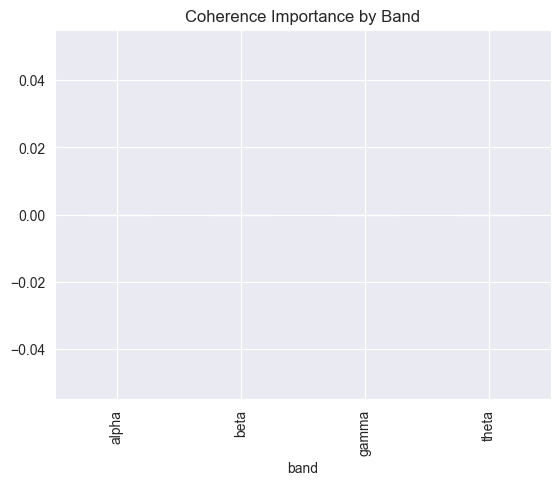

In [28]:
def coh_band(name):
    if name.startswith("coh_"):
        return name.split("_")[-1]
    return None

coh_df = importance_df[importance_df["feature"].str.startswith("coh_")].copy()
coh_df["band"] = coh_df["feature"].apply(coh_band)

coh_band_importance = (
    coh_df.groupby("band")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\nCoherence importance by band:")
print(coh_band_importance)

coh_band_importance.plot(kind="bar", title="Coherence Importance by Band")
plt.show()


Top channels:
channel
Oz      0.090974
T8      0.090945
O1      0.081110
Fpz     0.052778
FT8     0.037067
PO7     0.034988
O2      0.034275
TP10    0.031734
T7      0.029447
Fp2     0.029224
PO4     0.026333
TP9     0.025951
AF7     0.023665
PO3     0.022021
FC6     0.020728
Name: importance, dtype: float32


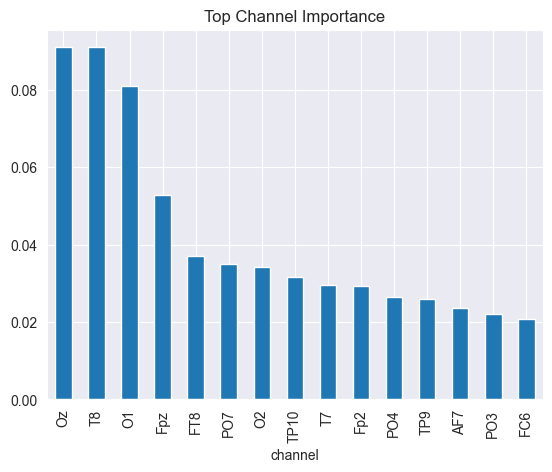

In [29]:
def extract_channel(name):
    # channel is always first token before "_"
    return name.split("_")[0]

ch_df = importance_df[~importance_df["feature"].str.startswith("coh_")].copy()
ch_df["channel"] = ch_df["feature"].apply(extract_channel)

channel_importance = (
    ch_df.groupby("channel")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop channels:")
print(channel_importance.head(15))

channel_importance.head(15).plot(kind="bar", title="Top Channel Importance")
plt.show()